In [27]:
import torch                         # import torch library
import torch.nn as nn                # import nn module for creating layers, models and functions
import numpy as np                   # import numpy library
from torch.autograd import Variable  # variable from numpy to torch
import matplotlib.pyplot as plt      # variable from numpy to torch

In [28]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") #set GPU as processing device
print(device)

cuda:0


In [29]:
m = 5   # motion equation parameter
l = 4   # motion equation parameter
k = 0.6 # motion equation parameter

iterations = 200
previous_validation_loss = np.Inf

class NN(nn.Module): #create neural network
    def __init__(self): #initialize 
        super(NN, self).__init__()
        self.hidden_layer1 = nn.Linear(1,128)    # first hidden layer, 128 neurons
        self.hidden_layer2 = nn.Linear(128,128)  # second hidden layer, 128 neurons
        self.output_layer  = nn.Linear(128,1)    # output layer, 1 output
        
    def forward(self,t):
        inputs=t
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))     # sigmoid activation function in hidden layer
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out)) # sigmoid activation function in hidden layer
        output = self.output_layer(layer2_out)                     # for regression, no activation is used in output layer
        return output

In [30]:
### Model
NN = NN()                                       #initialize neural network
NN = NN.to(device)                              #send neural network to GPU
mse_cost_function = torch.nn.MSELoss()          #mean squared error loss function
optimizer = torch.optim.Adam(NN.parameters())   #Adam optimizer for parameter update 

In [31]:
## PDE as loss function.
def f(t, NN):
    x = NN(t) #the dependent variable x is given by the network based on independent variable t
    ## Based on our f = m*d2x/dt2 + l*dx/dt + k*x, we need d2x/dt2 and dx/dt
    x_t = torch.autograd.grad(x.sum(), t, create_graph=True)[0] #dx/dt
    x_t2 = torch.autograd.grad(x_t.sum(),t,create_graph=True)[0] #d2x/dt2
    pde = m*x_t2 + l*x_t + k*x #second order motion pde
    return pde

In [32]:
## Data from Boundary Conditions
# x(0)=0;
# dx(0)/dt=0;

## BC provides datapoints for training
# BC tells us that for time t=0, the value of x and dx/dt is 0.
# Take say 500 random numbers of t
t_bc = np.zeros((500,1))

# Compute x based on BC
x_bc  = np.zeros((500,1))
x_bc2 = np.zeros((500,1))

In [33]:
### Training / Fitting
L = []                    # Creating empty list for gathering loss values

for epoch in range(iterations):
    
    # Loss based on boundary conditions
    pt_x_bc = Variable(torch.from_numpy(x_bc).float(), requires_grad=False).to(device) #boundary condition 1 to Pytorch tensor
    pt_t_bc = Variable(torch.from_numpy(t_bc).float(), requires_grad=False).to(device) #boundary condition 1 to Pytorch tensor
    
    net_bc_out = NN(pt_t_bc) #output of NN(t) for BC x(0)=0
    mse_u1 = mse_cost_function(net_bc_out, pt_x_bc) #Computing MSE loss
    
    # Loss based on boundary conditions
    pt_x_bc2 = Variable(torch.from_numpy(x_bc2).float(), requires_grad=False).to(device) #boundary condition 2 to Pytorch tensor
    pt_t_bc = Variable(torch.from_numpy(t_bc).float(), requires_grad=False).to(device) #boundary condition 2 to Pytorch tensor
    
    net_bc_out = NN(pt_t_bc) #output of NN(t) for BC dx(0)/dt=0
    mse_u2 = mse_cost_function(net_bc_out, pt_x_bc2) #Computing MSE loss
    
    # Loss based on PDE
    t_collocation = np.random.uniform(low=0.0, high=1.0, size=(500,1))
    all_zeros = np.zeros((500,1))
    
    pt_t_collocation = Variable(torch.from_numpy(t_collocation).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out = f(pt_t_collocation, NN) # output of f(t,NN)
    mse_f = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_f + mse_u1 + mse_u2
    
    loss.backward() #Computing gradients using backward propagation
    optimizer.step() #Equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta
    optimizer.zero_grad() #Make the gradients zero after each epoch and prevent cumulative gradientes
    
    loss_np = loss.data.cpu().numpy()
    L = np.append(L,loss_np)

    with torch.autograd.no_grad():
        if epoch % 10 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

0 Traning Loss: tensor(0.0633, device='cuda:0')
10 Traning Loss: tensor(0.0044, device='cuda:0')
20 Traning Loss: tensor(0.0047, device='cuda:0')
30 Traning Loss: tensor(0.0004, device='cuda:0')
40 Traning Loss: tensor(2.1121e-05, device='cuda:0')
50 Traning Loss: tensor(6.8300e-05, device='cuda:0')
60 Traning Loss: tensor(3.4109e-05, device='cuda:0')
70 Traning Loss: tensor(7.6009e-06, device='cuda:0')
80 Traning Loss: tensor(5.8296e-07, device='cuda:0')
90 Traning Loss: tensor(1.6350e-06, device='cuda:0')
100 Traning Loss: tensor(1.7433e-06, device='cuda:0')
110 Traning Loss: tensor(3.0212e-07, device='cuda:0')
120 Traning Loss: tensor(1.4881e-07, device='cuda:0')
130 Traning Loss: tensor(1.0429e-07, device='cuda:0')
140 Traning Loss: tensor(3.1744e-08, device='cuda:0')
150 Traning Loss: tensor(2.1161e-08, device='cuda:0')
160 Traning Loss: tensor(1.0648e-08, device='cuda:0')
170 Traning Loss: tensor(3.6814e-09, device='cuda:0')
180 Traning Loss: tensor(2.7890e-09, device='cuda:0')
1

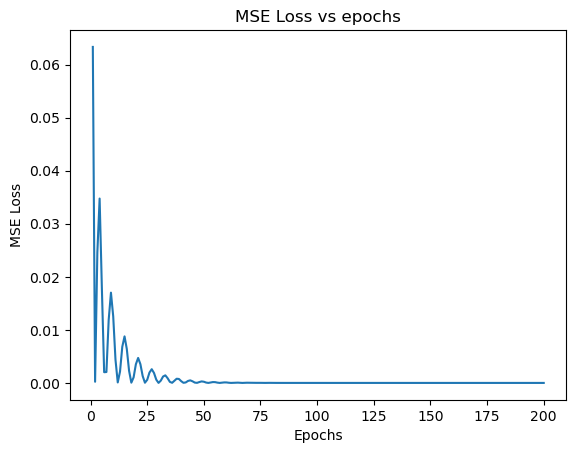

In [35]:
# plotting results
ep = np.linspace(1,iterations,iterations)
plt.plot(ep,L)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()